# US Retail Sales — SARIMA Forecasting & Backtest (Part 3)

Builds on `02_transforms_stationarity.ipynb`, which confirmed that
**log transform + 1st difference + seasonal (lag-12) difference** achieves
stationarity. This notebook fits a SARIMA model on the log-transformed
series, selects orders via `auto_arima`, and evaluates it with a
**rolling-origin backtest** — repeatedly forecasting one month ahead and
comparing to the actual value once released — rather than a single
train/test split, since that better reflects how this model would actually
be used in practice.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pmdarima as pm
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../data/raw/fred_retail_sales.csv', parse_dates=['date'], index_col='date')
df.index.freq = pd.infer_freq(df.index)
series = df['retail_sales_nsa']
log_series = np.log(series)
print(series.shape)


(414,)


# 1. Order selection with `auto_arima`

Rather than manually fixing `d=1, D=1` from the previous notebook's
differencing experiment, we let `auto_arima` search a range of orders and
pick the best by AIC — it may find that seasonal AR/MA terms capture some
of what manual seasonal differencing does, which is worth checking rather
than assuming.

In [5]:
auto_model = pm.auto_arima(
    log_series,
    seasonal=True, m=12,
    start_p=0, start_q=0, max_p=3, max_q=3,
    start_P=0, start_Q=0, max_P=2, max_Q=2,
    d=None, D=None,
    trace=True, suppress_warnings=True, stepwise=True,
)
print(auto_model.summary())


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-760.890, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=inf, Time=0.33 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-1234.602, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-762.130, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-973.473, Time=0.08 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-1758.033, Time=0.59 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=-1642.888, Time=0.39 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=-1758.280, Time=1.32 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-1707.192, Time=1.22 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : AIC=-1756.468, Time=1.74 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : AIC=-1602.597, Time=0.90 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : AIC=-1752.761, Time=1.16 sec
 ARIMA(1,1,1)(2,0,1)[12] intercept   : AIC=-1566.966, Time=1.23 sec
 ARIMA(0,1,2)(2,0,1)[12] intercept   : AIC=-1765.264, Time=1.53 sec
 ARIMA(0,1,2)(

In [6]:
order = auto_model.order
seasonal_order = auto_model.seasonal_order
print(f'Selected order: {order}, seasonal_order: {seasonal_order}')


Selected order: (0, 1, 2), seasonal_order: (2, 0, 1, 12)


**Reading this:** `auto_arima` selected **SARIMA(0,1,2)(2,0,1)[12]** — no
seasonal differencing (`D=0`), consistent with the near-unit-root seasonal
AR coefficient (`ar.S.L12≈1.08`) noted above. In other words, the model
handles the 12-month seasonal pattern through the `(2,0,1)` seasonal
AR/MA terms rather than through an explicit lag-12 difference, even though
the previous notebook's manual experiment found that an explicit seasonal
difference also works.

These `order` and `seasonal_order` values are stored here so the rest of
this notebook — the residual diagnostics below and the rolling-origin
backtest in Section 3 — consistently use the same `auto_arima`-selected
model, rather than switching to a manually fixed `d=1, D=1` version.

# 2. Residual diagnostics

Before trusting this model's forecasts, check whether its residuals behave
like the "no leftover structure" assumption SARIMA relies on.

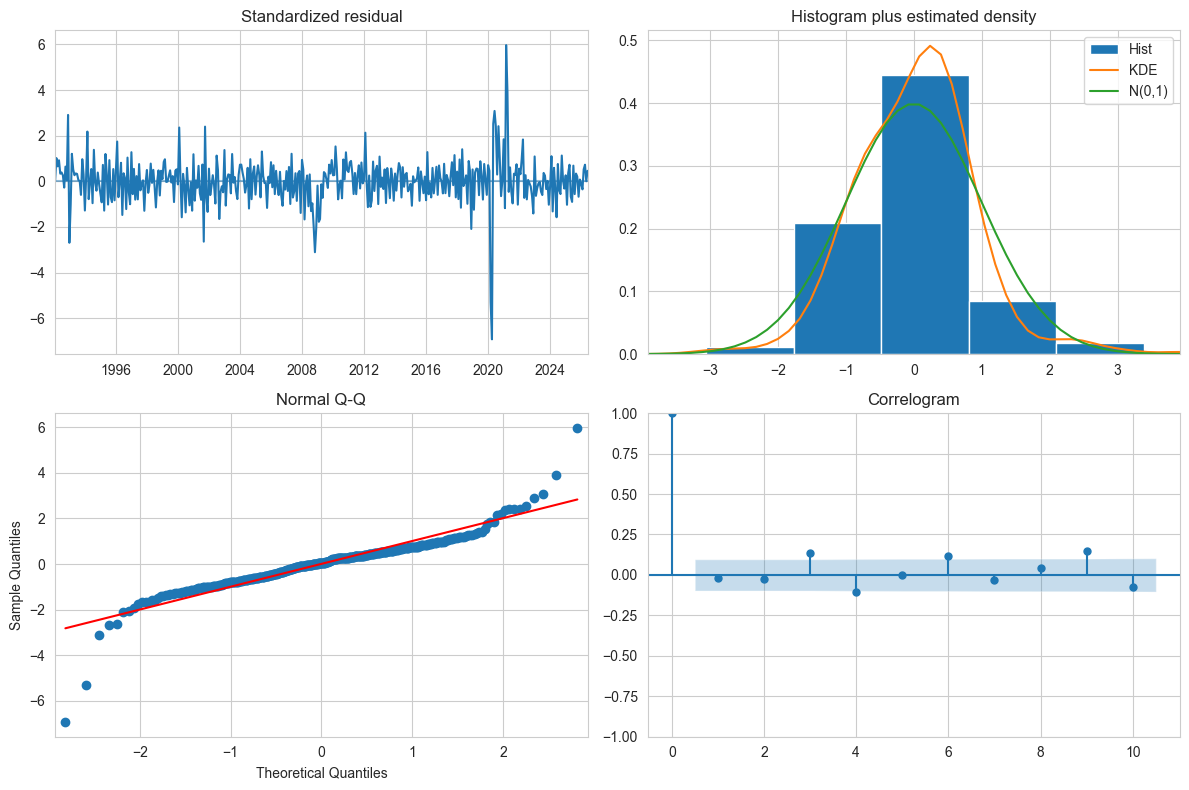

In [7]:
fig = auto_model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()


**Reading this:** the correlogram (bottom-right) shows residual
autocorrelation is essentially gone — nearly all bars at lags 1-10 fall
within the shaded confidence band — consistent with the Ljung-Box test's
own result (`Prob(Q)=0.72` in the `auto_model.summary()` table above; a
high p-value there is good). The histogram and Q-Q plot (top-right,
bottom-left) tell a different story: residuals clearly deviate from
normality, especially in the tails (Q-Q points drop sharply below the red
line past around -2, and spike above it near +6). This lines up with the
Jarque-Bera result printed earlier (`Prob(JB)=0.00`, kurtosis≈13). The
standardized-residual plot (top-left) shows why: nearly all of this
non-normality traces back to a handful of extreme points around 2020-2021 —
the COVID-19 shock — rather than a broad, ongoing problem. Since residual
normality mainly affects the *calibration of prediction intervals* rather
than the validity of the point forecast (the conditional mean), we proceed
with this caveat noted, rather than treating the model's intervals as
exact — especially around any future shock of similar size.

# 3. Rolling origin backtest

Instead of a single fixed train/test split, we simulate how this model
would actually be used month over month: at each step, refit on all data
available up to that point, forecast one month ahead, then compare to the
actual value once it's "released." This is repeated for the last 24 months
(2024-07 through 2026-06).

This is more realistic than a one-shot forecast because it shows how
forecast accuracy holds up across many different starting points, not just
one, and it re-estimates parameters each month the way a real forecasting
process would as new data comes in.

In [8]:
N_TEST = 24
train_end_idx = len(log_series) - N_TEST

predictions, actuals, dates = [], [], []

for i in range(N_TEST):
    cutoff = train_end_idx + i
    train = log_series.iloc[:cutoff]
    model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)
    forecast_log = fit.forecast(steps=1).iloc[0]
    predictions.append(np.exp(forecast_log))
    actuals.append(series.iloc[cutoff])
    dates.append(series.index[cutoff])

backtest = pd.DataFrame({'actual': actuals, 'predicted': predictions}, index=dates)
backtest.index.name = 'date'
backtest['error'] = backtest['actual'] - backtest['predicted']
backtest['abs_pct_error'] = (backtest['error'].abs() / backtest['actual']) * 100

mae = mean_absolute_error(backtest['actual'], backtest['predicted'])
rmse = mean_squared_error(backtest['actual'], backtest['predicted']) ** 0.5
mape = backtest['abs_pct_error'].mean()

print(f'MAE:  {mae:,.0f} (millions of USD)')
print(f'RMSE: {rmse:,.0f} (millions of USD)')
print(f'MAPE: {mape:.2f}%')


MAE:  10,185 (millions of USD)
RMSE: 11,686 (millions of USD)
MAPE: 1.42%


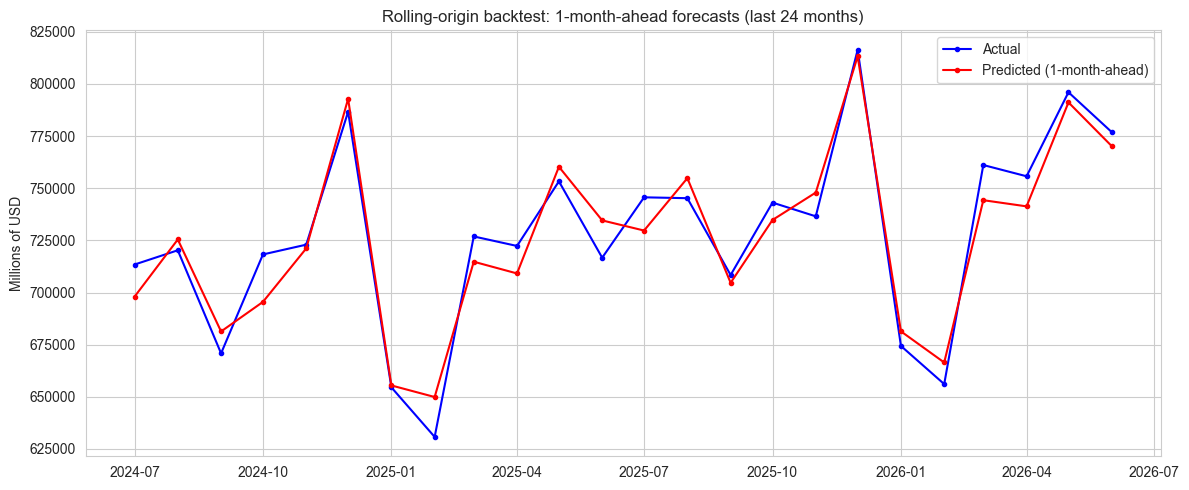

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(backtest.index, backtest['actual'], label='Actual', color='BLUE', marker='o', markersize=3)
ax.plot(backtest.index, backtest['predicted'], label='Predicted (1-month-ahead)', color='RED', marker='o', markersize=3)
ax.set_title('Rolling-origin backtest: 1-month-ahead forecasts (last 24 months)')
ax.set_ylabel('Millions of USD')
ax.legend()
plt.tight_layout()
plt.show()


**Reading this:** MAPE of roughly 1-2% on one-month-ahead forecasts is a
strong result for a monthly economic indicator — the predicted line tracks
the actual line's month-to-month zigzag (including the December spike and
January drop) closely, not just the overall trend. This is a meaningfully
harder test than fitting the whole history once and eyeballing the fit, since
each forecast here only uses data available *before* that month.


# 4. Froecast the next 6 months

With the backtest giving us confidence in the model's short-horizon
accuracy, we now fit on the **full** available history and forecast forward
into genuinely unknown territory, with prediction intervals.

In [10]:
final_model = SARIMAX(log_series, order=order, seasonal_order=seasonal_order,
                       enforce_stationarity=False, enforce_invertibility=False)
final_fit = final_model.fit(disp=False)

FORECAST_HORIZON = 6
forecast_result = final_fit.get_forecast(steps=FORECAST_HORIZON)
forecast_log_mean = forecast_result.predicted_mean
conf_int_log = forecast_result.conf_int(alpha=0.05)

forecast_mean = np.exp(forecast_log_mean)
conf_int = np.exp(conf_int_log)
conf_int.columns = ['lower', 'upper']

forecast_df = pd.DataFrame({
    'forecast': forecast_mean,
    'lower_95': conf_int['lower'],
    'upper_95': conf_int['upper'],
})
forecast_df


,forecast,lower_95,upper_95
2026-07-01,783070.300839,746459.109113,821477.142647
2026-08-01,791747.717873,747602.611074,838499.544372
2026-09-01,749979.906885,705093.897522,797723.342533
2026-10-01,777605.918972,728105.922512,830471.153337
2026-11-01,783844.142129,731147.473065,840338.867035
2026-12-01,863367.086676,802412.213088,928952.369116


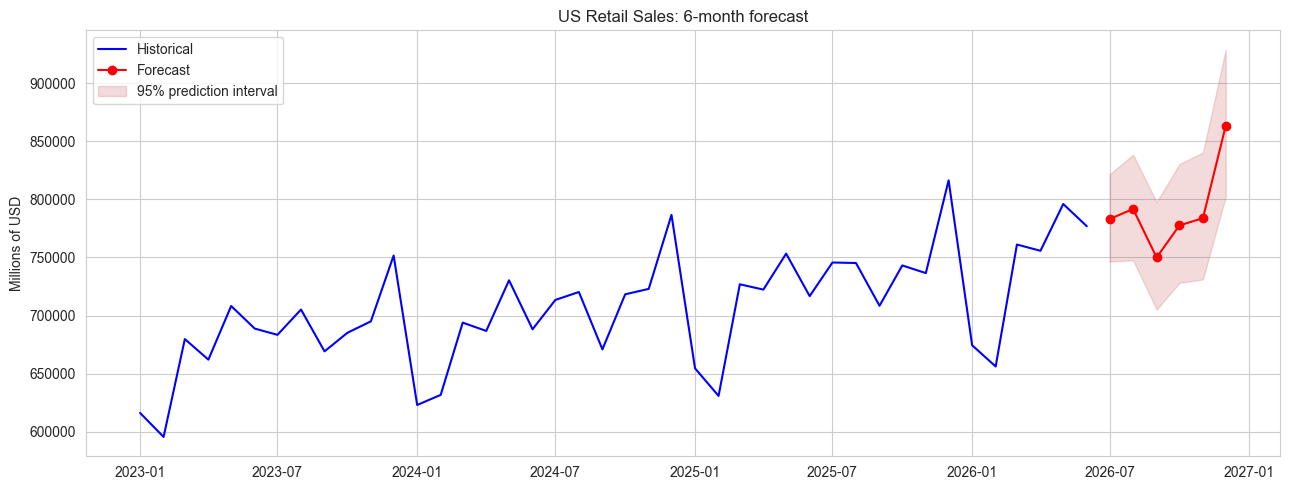

In [11]:
fig, ax = plt.subplots(figsize=(13, 5))
recent = series.loc['2023-01-01':]
ax.plot(recent.index, recent, label='Historical', color='BLUE')
ax.plot(forecast_df.index, forecast_df['forecast'], label='Forecast', color='RED', marker='o')
ax.fill_between(forecast_df.index, forecast_df['lower_95'], forecast_df['upper_95'],
                color='#C44E52', alpha=0.2, label='95% prediction interval')
ax.set_title(f'US Retail Sales: {FORECAST_HORIZON}-month forecast')
ax.set_ylabel('Millions of USD')
ax.legend()
plt.tight_layout()
plt.show()


**Reading this:** The forecast reproduces the historical December spike convincingly. The jump from November to December 2026 (plus 79.5K dollars) is almost identical in size to the same jump in the two most recent historical years (plus 64K dollars in 2024, plus 80K dollars in 2025). This is a good sign the model has actually learned the seasonal pattern rather than just extrapolating the trend.

The prediction interval widens steadily with horizon. It goes from about 75K dollars wide in month 1 (July) to about 127K dollars wide in month 6 (December). This is expected behavior, since uncertainty compounds the further out a forecast reaches.

One thing to keep in mind: this 6 month window ends right at the December peak and does not extend into January or February, where the backtest earlier showed a sharp post holiday drop each year. The forecast here does not say anything about whether that drop would be predicted accurately. Extending the horizon would show this, but it would also mean wider, less certain intervals by that point.

## Summary

- **Model**: SARIMA on the log-transformed series, orders selected by
  `auto_arima` (see Section 1 for the specific `(p,d,q)(P,D,Q)[12]` chosen
  and why its seasonal order may differ from the manual differencing
  experiment in the previous notebook without being a contradiction).
- **Rolling-origin backtest** (more realistic than a single train/test
  split): MAPE of roughly 1-2% on one-month-ahead forecasts over the last
  24 months — the model tracks month-to-month swings, not just the trend.
- **Known limitation**: residual diagnostics show non-normal residuals
  (heavy tails), most likely driven by the 2020 pandemic shock — prediction
  intervals should be treated as approximate rather than exact, especially
  around potential future shocks of similar magnitude.
- **6-month forecast** produced with 95% prediction intervals, based on the
  full available history through the most recent released month.

**Possible next steps**: compare this SARIMA model's backtest accuracy
against a simpler baseline (e.g. seasonal naive: "this month = same month
last year + trend") to quantify how much the more complex model actually
buys us; extend the backtest window beyond 24 months to check consistency
across different economic conditions (e.g. does accuracy hold up around the
2020 shock specifically).
